In [3]:
# Project NOVA — DCF Valuation Analysis
# Amazon + NVIDIA Hypothetical Merger
# Built by Opene-Terry Josephine

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set professional dark style
plt.rcParams['figure.facecolor'] = '#0a0a0a'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully. Project NOVA ready.")


Libraries loaded successfully. Project NOVA ready.


In [4]:
# Load the S&P 500 financial data
flow = pd.read_csv('FS_sp500_flow.csv')
income = pd.read_csv('FS_sp500_income.csv')

# Quick check - confirm data loaded correctly
print("Flow statement shape:", flow.shape)
print("Income statement shape:", income.shape)
print("\nTickers available (sample):", sorted(flow['Ticker'].unique())[:10])

# Confirm our two companies are in the dataset
for ticker in ['AMZN', 'NVDA']:
    in_flow = ticker in flow['Ticker'].values
    in_income = ticker in income['Ticker'].values
    print(f"\n{ticker} in flow data: {in_flow}")
    print(f"{ticker} in income data: {in_income}")

Flow statement shape: (2668, 7)
Income statement shape: (3278, 7)

Tickers available (sample): ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABT', 'ACN', 'ADBE']

AMZN in flow data: True
AMZN in income data: True

NVDA in flow data: True
NVDA in income data: True


In [5]:
# Function to extract a specific metric for a company
def get_metric(df, ticker, metric):
    row = df[(df['Ticker']==ticker) & (df['Breakdown']==metric)]
    if len(row) == 0:
        return [0, 0, 0, 0]
    # Return oldest to newest (Before_3, Before_2, Before_1, Recent)
    return row[['Before_3','Before_2','Before_1','Recent']].values[0].tolist()

# Years label
years = ['FY2019', 'FY2020', 'FY2021', 'FY2022']

# Extract AMZN metrics
amzn_rev   = get_metric(income, 'AMZN', 'totalRevenue')
amzn_gp    = get_metric(income, 'AMZN', 'grossProfit')
amzn_ni    = get_metric(income, 'AMZN', 'netIncome')
amzn_ocf   = get_metric(flow,   'AMZN', 'totalCashFromOperatingActivities')
amzn_capex = get_metric(flow,   'AMZN', 'capitalExpenditures')
amzn_dep   = get_metric(flow,   'AMZN', 'depreciation')

# Extract NVDA metrics
nvda_rev   = get_metric(income, 'NVDA', 'totalRevenue')
nvda_gp    = get_metric(income, 'NVDA', 'grossProfit')
nvda_ni    = get_metric(income, 'NVDA', 'netIncome')
nvda_ocf   = get_metric(flow,   'NVDA', 'totalCashFromOperatingActivities')
nvda_capex = get_metric(flow,   'NVDA', 'capitalExpenditures')
nvda_dep   = get_metric(flow,   'NVDA', 'depreciation')

# Calculate NOVA combined metrics
nova_rev   = [a + n for a, n in zip(amzn_rev,   nvda_rev)]
nova_gp    = [a + n for a, n in zip(amzn_gp,    nvda_gp)]
nova_ni    = [a + n for a, n in zip(amzn_ni,    nvda_ni)]
nova_ocf   = [a + n for a, n in zip(amzn_ocf,   nvda_ocf)]
nova_capex = [a + n for a, n in zip(amzn_capex, nvda_capex)]
nova_fcf   = [o + c for o, c in zip(nova_ocf,   nova_capex)]

# Print summary to verify
print("=== NOVA COMBINED FINANCIALS (USD Millions) ===")
print(f"\n{'Year':<10} {'Revenue':>12} {'Gross Profit':>14} {'Net Income':>12} {'FCF':>12}")
print("-" * 62)
for i, yr in enumerate(years):
    print(f"{yr:<10} {nova_rev[i]/1e6:>12,.0f} {nova_gp[i]/1e6:>14,.0f} "
          f"{nova_ni[i]/1e6:>12,.0f} {nova_fcf[i]/1e6:>12,.0f}")

=== NOVA COMBINED FINANCIALS (USD Millions) ===

Year            Revenue   Gross Profit   Net Income          FCF
--------------------------------------------------------------
FY2019          130,558         49,427        8,679       17,392
FY2020          114,179         49,744       10,019       -6,293
FY2021          119,587         53,119       10,152          926
FY2022          117,915         52,513        5,620       -7,138


In [6]:
# ===========================
# DCF ASSUMPTIONS
# Mirroring Excel ASSUMPTIONS sheet
# ===========================

# Discount rate
wacc = 0.095

# Terminal growth rate
tgr = 0.030

# Tax rate
tax_rate = 0.12

# Net debt (USD actual, not millions)
net_debt = 32_000_000_000

# Revenue growth rates per year
growth_rates = [0.12, 0.14, 0.13, 0.10, 0.08]

# FCF margins per year
fcf_margins = [0.085, 0.090, 0.095, 0.100, 0.105]

# Synergy premiums per year
synergy = [0.00, 0.05, 0.08, 0.08, 0.08]

# Base revenue from FY2022 (actual dollars)
base_revenue = nova_rev[-1]

# Forecast year labels
forecast_years = ['FY2023', 'FY2024', 'FY2025', 'FY2026', 'FY2027']

print("=== DCF ASSUMPTIONS ===")
print(f"WACC:                {wacc*100:.1f}%")
print(f"Terminal Growth:     {tgr*100:.1f}%")
print(f"Tax Rate:            {tax_rate*100:.1f}%")
print(f"Net Debt:            ${net_debt/1e9:.1f}B")
print(f"Base Revenue:        ${base_revenue/1e6:,.0f}M")
print(f"\nRevenue Growth:      {[f'{g*100:.0f}%' for g in growth_rates]}")
print(f"FCF Margins:         {[f'{m*100:.1f}%' for m in fcf_margins]}")
print(f"Synergy Premiums:    {[f'{s*100:.0f}%' for s in synergy]}")

=== DCF ASSUMPTIONS ===
WACC:                9.5%
Terminal Growth:     3.0%
Tax Rate:            12.0%
Net Debt:            $32.0B
Base Revenue:        $117,915M

Revenue Growth:      ['12%', '14%', '13%', '10%', '8%']
FCF Margins:         ['8.5%', '9.0%', '9.5%', '10.0%', '10.5%']
Synergy Premiums:    ['0%', '5%', '8%', '8%', '8%']


In [7]:
# ===========================
# DCF CALCULATION
# ===========================

# Step 1 — Project revenues
proj_revenue = []
for i, g in enumerate(growth_rates):
    if i == 0:
        r = base_revenue * (1 + g) * (1 + synergy[i])
    else:
        r = proj_revenue[-1] * (1 + g) * (1 + synergy[i])
    proj_revenue.append(r)

# Step 2 — Project FCFs
proj_fcf = [r * m for r, m in zip(proj_revenue, fcf_margins)]

# Step 3 — Calculate discount factors
discount_factors = [1 / (1 + wacc)**(i+1) for i in range(5)]

# Step 4 — Calculate present values
pv_fcfs = [fcf * df for fcf, df in zip(proj_fcf, discount_factors)]

# Step 5 — Terminal value
terminal_value = (proj_fcf[-1] * (1 + tgr)) / (wacc - tgr)
pv_terminal = terminal_value * discount_factors[-1]

# Step 6 — Enterprise and equity value
enterprise_value = sum(pv_fcfs) + pv_terminal
equity_value = enterprise_value - net_debt

# Print results
print("=== PROJECT NOVA — DCF RESULTS ===")
print(f"\n{'Metric':<30} {'Value':>15}")
print("-" * 47)
print(f"\n--- PROJECTIONS ---")
for i, yr in enumerate(forecast_years):
    print(f"{'Revenue ' + yr:<30} ${proj_revenue[i]/1e6:>12,.0f}M")
print()
for i, yr in enumerate(forecast_years):
    print(f"{'FCF ' + yr:<30} ${proj_fcf[i]/1e6:>12,.0f}M")

print(f"\n--- VALUATION ---")
print(f"{'Sum of PV FCFs':<30} ${sum(pv_fcfs)/1e6:>12,.0f}M")
print(f"{'Terminal Value':<30} ${terminal_value/1e6:>12,.0f}M")
print(f"{'PV of Terminal Value':<30} ${pv_terminal/1e6:>12,.0f}M")
print(f"{'Enterprise Value':<30} ${enterprise_value/1e6:>12,.0f}M")
print(f"{'Less Net Debt':<30} ${net_debt/1e6:>12,.0f}M")
print(f"{'Equity Value':<30} ${equity_value/1e6:>12,.0f}M")

=== PROJECT NOVA — DCF RESULTS ===

Metric                                   Value
-----------------------------------------------

--- PROJECTIONS ---
Revenue FY2023                 $     132,065M
Revenue FY2024                 $     158,082M
Revenue FY2025                 $     192,923M
Revenue FY2026                 $     229,192M
Revenue FY2027                 $     267,330M

FCF FY2023                     $      11,226M
FCF FY2024                     $      14,227M
FCF FY2025                     $      18,328M
FCF FY2026                     $      22,919M
FCF FY2027                     $      28,070M

--- VALUATION ---
Sum of PV FCFs                 $      69,849M
Terminal Value                 $     444,796M
PV of Terminal Value           $     282,547M
Enterprise Value               $     352,396M
Less Net Debt                  $      32,000M
Equity Value                   $     320,396M


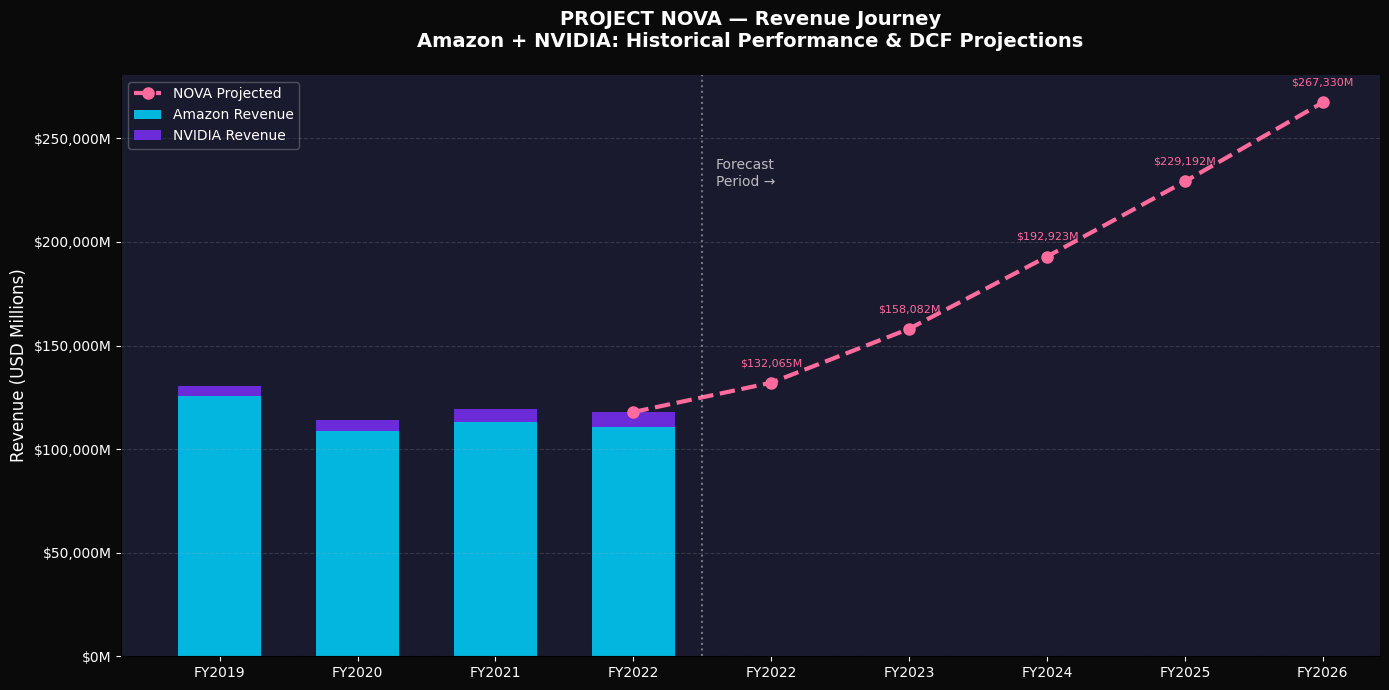

Chart 1 saved.


In [8]:
# ===========================
# CHART 1: REVENUE STORY
# Historical + Projected Revenue
# ===========================

fig, ax = plt.subplots(figsize=(14, 7))

# Historical data in millions
amzn_hist = [x/1e6 for x in amzn_rev]
nvda_hist = [x/1e6 for x in nvda_rev]
nova_hist = [x/1e6 for x in nova_rev]
nova_proj = [x/1e6 for x in proj_revenue]

# X positions
hist_x = np.arange(4)
proj_x = np.arange(3, 9)

# Stacked bars for historical
bars1 = ax.bar(hist_x, amzn_hist, 
               color='#00d2ff', alpha=0.85, 
               label='Amazon Revenue', width=0.6)
bars2 = ax.bar(hist_x, nvda_hist, 
               bottom=amzn_hist,
               color='#7b2ff7', alpha=0.85, 
               label='NVIDIA Revenue', width=0.6)

# Projected line for NOVA
all_nova = [nova_hist[-1]] + nova_proj
ax.plot(proj_x, all_nova,
        color='#ff6b9d', linewidth=3,
        marker='o', markersize=8,
        label='NOVA Projected', linestyle='--')

# Forecast divider line
ax.axvline(x=3.5, color='white', 
           linestyle=':', alpha=0.4, linewidth=1.5)
ax.text(3.6, max(all_nova)*0.85,
        'Forecast\nPeriod →', 
        color='white', fontsize=10, alpha=0.7)

# Labels on projected points
for i, (x, val) in enumerate(zip(proj_x[1:], nova_proj)):
    ax.annotate(f'${val:,.0f}M',
                xy=(x, val),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=8,
                color='#ff6b9d')

# Formatting
all_labels = ['FY2019', 'FY2020', 'FY2021', 'FY2022',
              '', 'FY2023', 'FY2024', 'FY2025', 'FY2026', 'FY2027']
ax.set_xticks(np.arange(9))
ax.set_xticklabels(['FY2019', 'FY2020', 'FY2021', 'FY2022',
                    'FY2022', 'FY2023', 'FY2024', 
                    'FY2025', 'FY2026'], fontsize=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
ax.set_ylabel('Revenue (USD Millions)', fontsize=12)
ax.set_title('PROJECT NOVA — Revenue Journey\n'
             'Amazon + NVIDIA: Historical Performance & DCF Projections',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', framealpha=0.3, fontsize=10)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('nova_revenue_story.png', dpi=150, 
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("Chart 1 saved.")

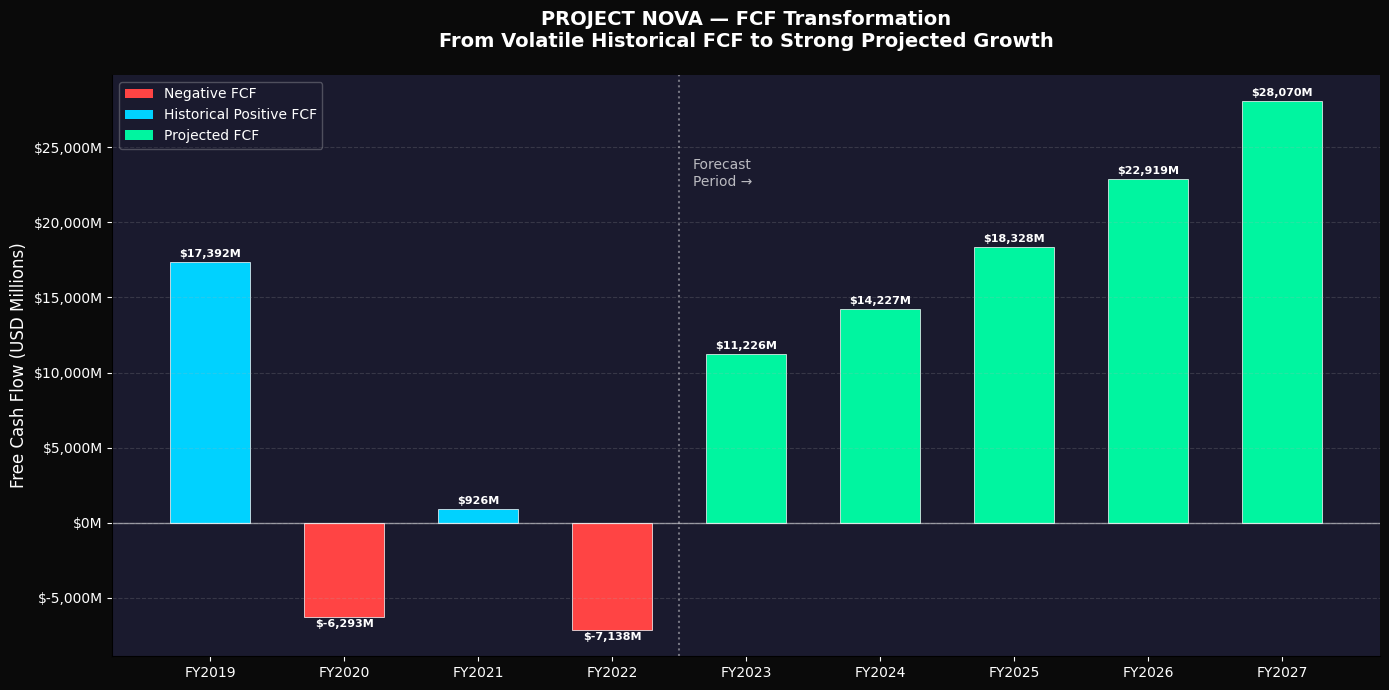

Chart 2 saved.


In [9]:
# ===========================
# CHART 2: FCF TRANSFORMATION
# Historical volatility → Projected growth
# ===========================

fig, ax = plt.subplots(figsize=(14, 7))

# All FCF values in millions
hist_fcf = [x/1e6 for x in nova_fcf]
proj_fcf_m = [x/1e6 for x in proj_fcf]

# All years combined
all_years = ['FY2019', 'FY2020', 'FY2021', 'FY2022',
             'FY2023', 'FY2024', 'FY2025', 'FY2026', 'FY2027']
all_fcf = hist_fcf + proj_fcf_m

# Colors — red for negative, blue for historical positive,
# green for projected
colors = []
for i, val in enumerate(all_fcf):
    if val < 0:
        colors.append('#ff4444')
    elif i < 4:
        colors.append('#00d2ff')
    else:
        colors.append('#00f5a0')

# Bar chart
bars = ax.bar(all_years, all_fcf,
              color=colors, 
              edgecolor='white',
              linewidth=0.5,
              width=0.6)

# Value labels on each bar
for bar, val in zip(bars, all_fcf):
    ypos = bar.get_height() + 200 if val >= 0 else bar.get_height() - 800
    ax.text(bar.get_x() + bar.get_width()/2,
            ypos, f'${val:,.0f}M',
            ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold')

# Zero line
ax.axhline(y=0, color='white', linewidth=1, alpha=0.5)

# Forecast divider
ax.axvline(x=3.5, color='white',
           linestyle=':', alpha=0.4, linewidth=1.5)
ax.text(3.6, max(proj_fcf_m)*0.8,
        'Forecast\nPeriod →',
        color='white', fontsize=10, alpha=0.7)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff4444', label='Negative FCF'),
    Patch(facecolor='#00d2ff', label='Historical Positive FCF'),
    Patch(facecolor='#00f5a0', label='Projected FCF')
]
ax.legend(handles=legend_elements,
          loc='upper left',
          framealpha=0.3, fontsize=10)

# Formatting
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
ax.set_ylabel('Free Cash Flow (USD Millions)', fontsize=12)
ax.set_title('PROJECT NOVA — FCF Transformation\n'
             'From Volatile Historical FCF to Strong Projected Growth',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('nova_fcf_transformation.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("Chart 2 saved.")

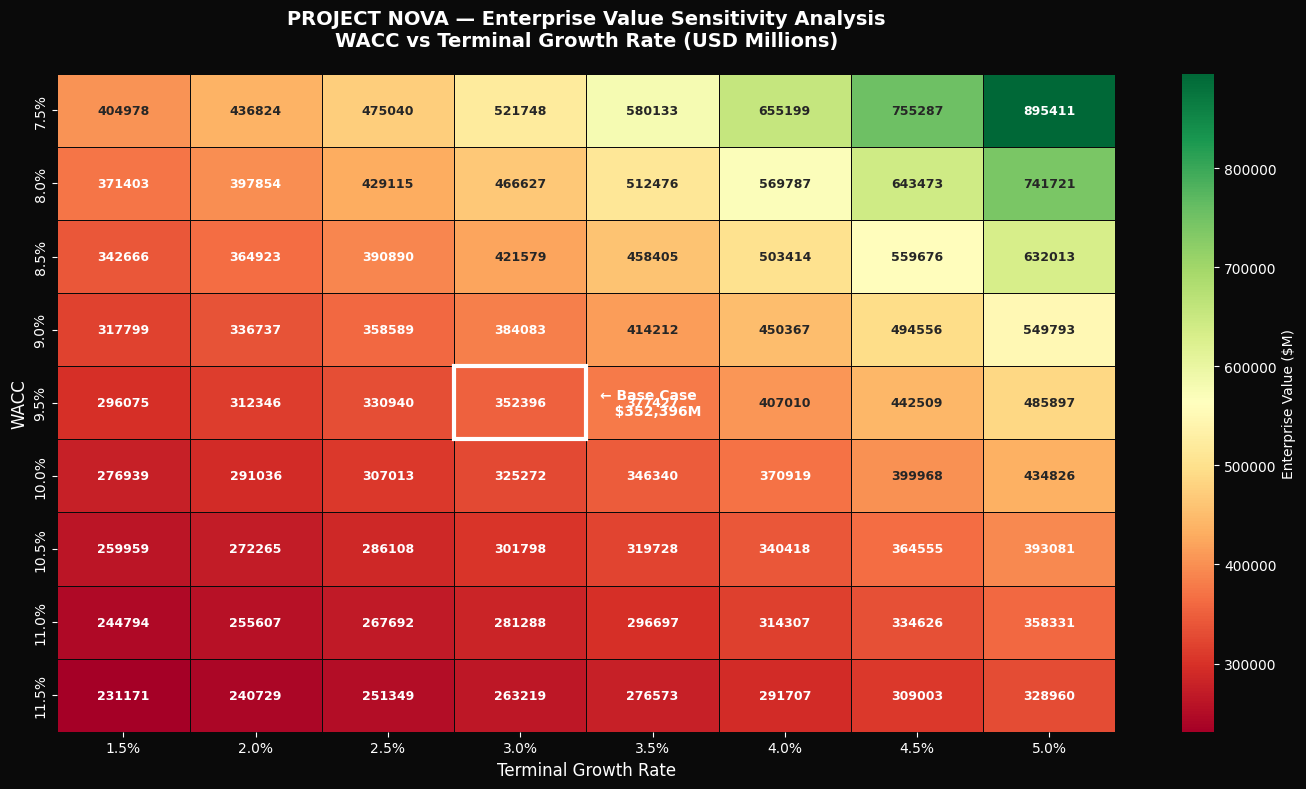

Chart 3 saved.


In [10]:
# ===========================
# CHART 3: SENSITIVITY HEATMAP
# WACC vs Terminal Growth Rate
# ===========================

# Build sensitivity data
wacc_range = np.arange(0.075, 0.120, 0.005)
tgr_range  = np.arange(0.015, 0.050, 0.005)

# Build the grid
sensitivity_data = []
for w in wacc_range:
    row = []
    for t in tgr_range:
        # Discount each FCF
        pv_f = sum([proj_fcf[i] / (1 + w)**(i+1) 
                    for i in range(5)])
        # Terminal value
        tv   = (proj_fcf[-1] * (1 + t)) / (w - t)
        pv_tv = tv / (1 + w)**5
        # Enterprise value
        ev_scenario = (pv_f + pv_tv) / 1e6
        row.append(round(ev_scenario, 0))
    sensitivity_data.append(row)

# Create DataFrame
wacc_labels = [f"{w*100:.1f}%" for w in wacc_range]
tgr_labels  = [f"{t*100:.1f}%" for t in tgr_range]
sensitivity_df = pd.DataFrame(sensitivity_data,
                               index=wacc_labels,
                               columns=tgr_labels)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')

sns.heatmap(sensitivity_df,
            annot=True,
            fmt=".0f",
            cmap="RdYlGn",
            linewidths=0.5,
            linecolor='#0a0a0a',
            ax=ax,
            annot_kws={"size": 9, "weight": "bold"},
            cbar_kws={'label': 'Enterprise Value ($M)'})

# Highlight base case
base_wacc_idx = wacc_labels.index('9.5%')
base_tgr_idx  = tgr_labels.index('3.0%')
ax.add_patch(plt.Rectangle(
    (base_tgr_idx, base_wacc_idx), 1, 1,
    fill=False, edgecolor='white', lw=3))
ax.text(base_tgr_idx + 1.1, base_wacc_idx + 0.5,
        '← Base Case\n   $352,396M',
        color='white', fontsize=10,
        va='center', fontweight='bold')

# Formatting
ax.set_title('PROJECT NOVA — Enterprise Value Sensitivity Analysis\n'
             'WACC vs Terminal Growth Rate (USD Millions)',
             fontsize=14, fontweight='bold',
             pad=20, color='white')
ax.set_xlabel('Terminal Growth Rate',
              fontsize=12, color='white')
ax.set_ylabel('WACC',
              fontsize=12, color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('nova_sensitivity_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("Chart 3 saved.")

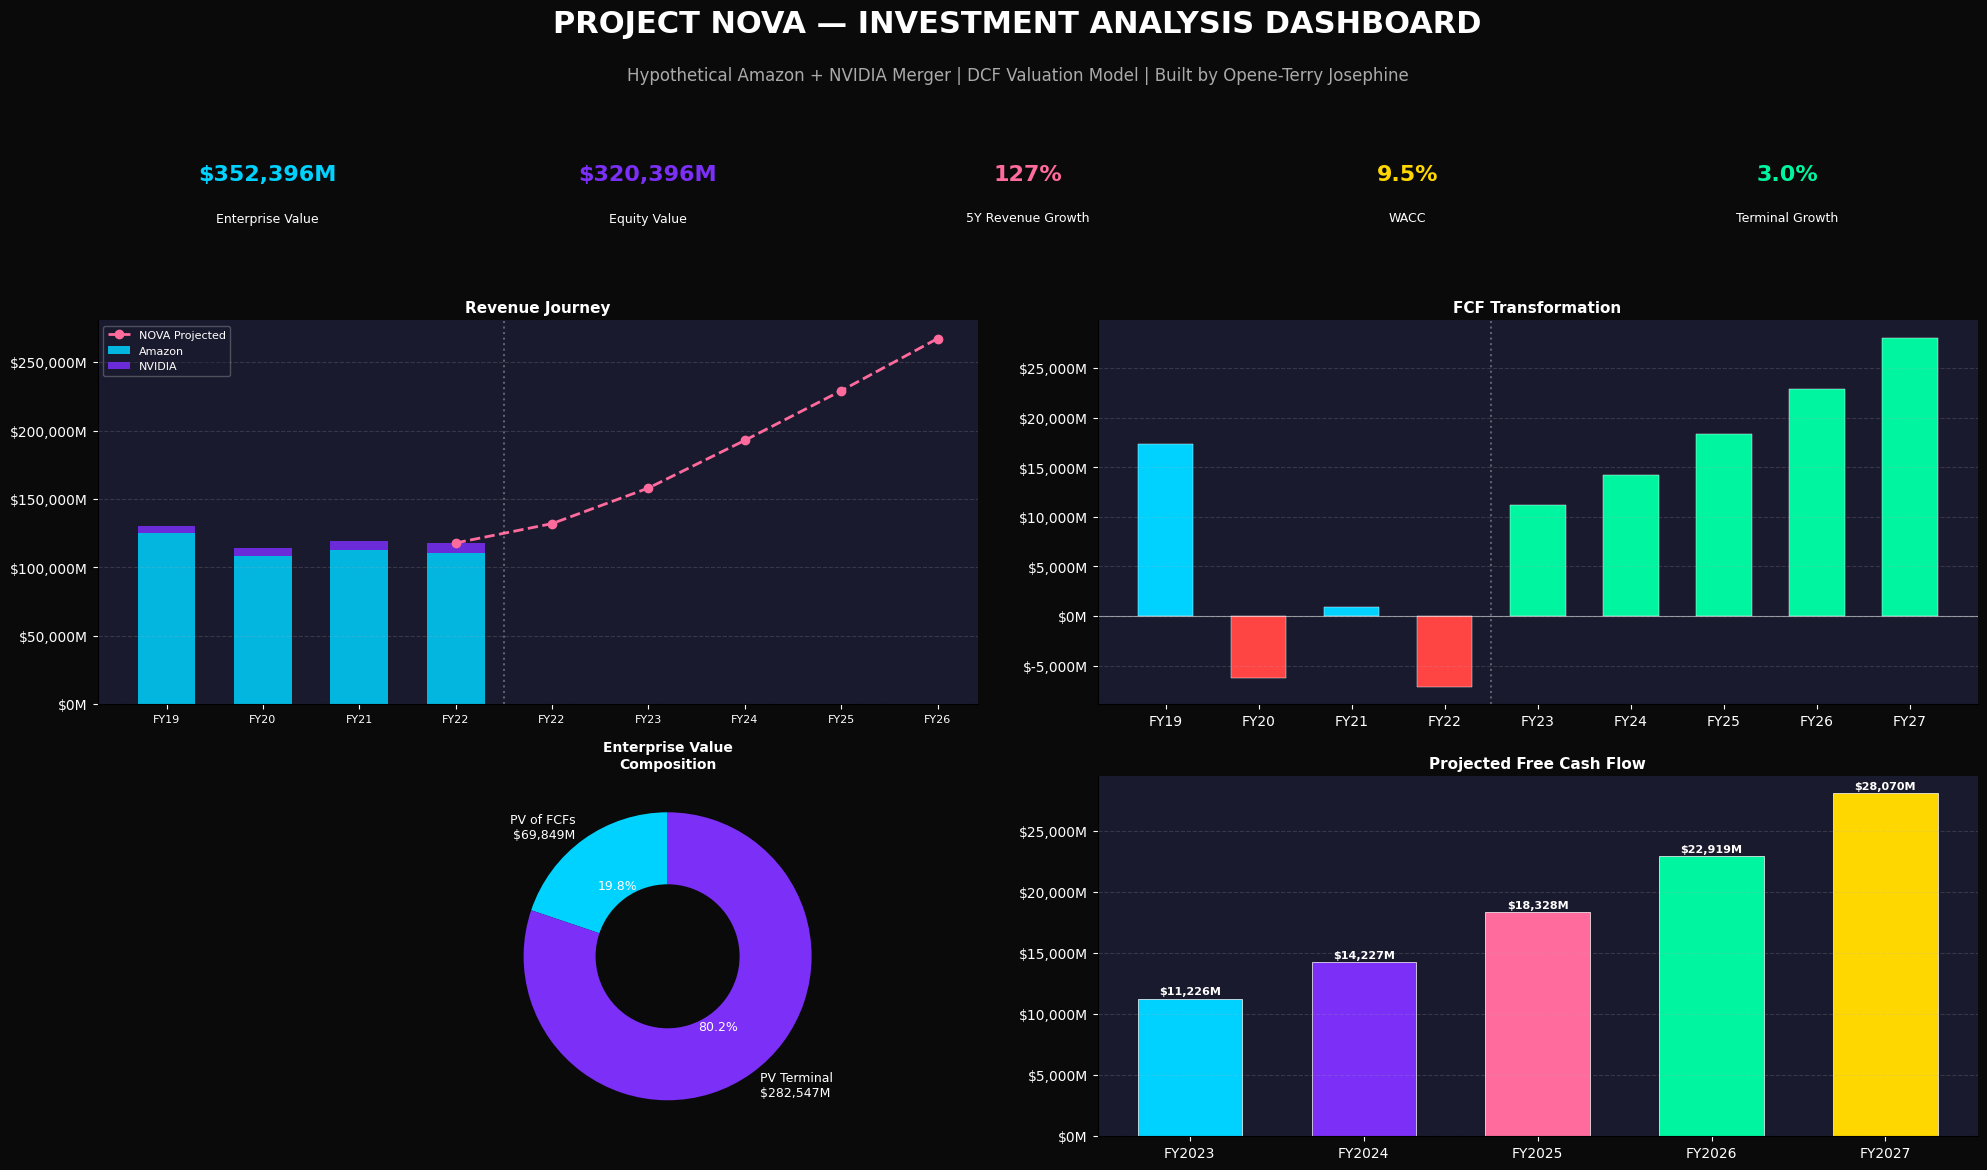

Dashboard saved.


In [11]:
# ===========================
# CHART 4: EXECUTIVE DASHBOARD
# Full Project NOVA Summary
# ===========================

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0a0a0a')

# --- TITLE ---
fig.text(0.5, 0.96,
         'PROJECT NOVA — INVESTMENT ANALYSIS DASHBOARD',
         ha='center', fontsize=22,
         fontweight='bold', color='white')
fig.text(0.5, 0.92,
         'Hypothetical Amazon + NVIDIA Merger | DCF Valuation Model | '
         'Built by Opene-Terry Josephine',
         ha='center', fontsize=12, color='#aaaaaa')

# --- KPI BOXES ---
kpis = [
    ('Enterprise Value',  f'$352,396M', '#00d2ff'),
    ('Equity Value',      f'$320,396M', '#7b2ff7'),
    ('5Y Revenue Growth', '127%',       '#ff6b9d'),
    ('WACC',              '9.5%',       '#ffd700'),
    ('Terminal Growth',   '3.0%',       '#00f5a0'),
]

for i, (label, value, color) in enumerate(kpis):
    ax_box = fig.add_axes([0.04 + i*0.19, 0.78, 0.17, 0.10])
    ax_box.set_facecolor(color + '22')
    ax_box.set_xlim(0, 1)
    ax_box.set_ylim(0, 1)
    ax_box.axis('off')
    for spine in ax_box.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
        spine.set_visible(True)
    ax_box.text(0.5, 0.62, value,
                ha='center', va='center',
                fontsize=16, fontweight='bold',
                color=color)
    ax_box.text(0.5, 0.25, label,
                ha='center', va='center',
                fontsize=9, color='white')

# --- CHART A: Revenue ---
ax1 = fig.add_axes([0.04, 0.40, 0.44, 0.32])
ax1.set_facecolor('#1a1a2e')

hist_fcf_m = [x/1e6 for x in nova_rev]
proj_rev_m = [x/1e6 for x in proj_revenue]
hist_x = np.arange(4)
proj_x = np.arange(3, 9)

ax1.bar(hist_x,
        [x/1e6 for x in amzn_rev],
        color='#00d2ff', alpha=0.85,
        label='Amazon', width=0.6)
ax1.bar(hist_x,
        [x/1e6 for x in nvda_rev],
        bottom=[x/1e6 for x in amzn_rev],
        color='#7b2ff7', alpha=0.85,
        label='NVIDIA', width=0.6)
ax1.plot(proj_x,
         [hist_fcf_m[-1]] + proj_rev_m,
         color='#ff6b9d', linewidth=2,
         marker='o', markersize=6,
         linestyle='--', label='NOVA Projected')
ax1.axvline(x=3.5, color='white',
            linestyle=':', alpha=0.3)
ax1.set_xticks(np.arange(9))
ax1.set_xticklabels(['FY19', 'FY20', 'FY21', 'FY22',
                     'FY22', 'FY23', 'FY24',
                     'FY25', 'FY26'],
                    fontsize=8, color='white')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
ax1.tick_params(colors='white')
ax1.set_title('Revenue Journey', color='white',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, framealpha=0.3)
ax1.grid(axis='y', alpha=0.2, linestyle='--')

# --- CHART B: FCF ---
ax2 = fig.add_axes([0.54, 0.40, 0.44, 0.32])
ax2.set_facecolor('#1a1a2e')

all_fcf_m = [x/1e6 for x in nova_fcf] + \
            [x/1e6 for x in proj_fcf]
all_yr = ['FY19', 'FY20', 'FY21', 'FY22',
          'FY23', 'FY24', 'FY25', 'FY26', 'FY27']
bar_colors = ['#ff4444' if v < 0 else
              '#00d2ff' if i < 4 else
              '#00f5a0'
              for i, v in enumerate(all_fcf_m)]

ax2.bar(all_yr, all_fcf_m,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.3, width=0.6)
ax2.axhline(y=0, color='white',
            linewidth=0.8, alpha=0.5)
ax2.axvline(x=3.5, color='white',
            linestyle=':', alpha=0.3)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
ax2.tick_params(colors='white')
ax2.set_title('FCF Transformation',
              color='white', fontsize=11,
              fontweight='bold')
ax2.grid(axis='y', alpha=0.2, linestyle='--')

# --- CHART C: Valuation Donut ---
ax3 = fig.add_axes([0.20, 0.04, 0.25, 0.30])
ax3.set_facecolor('#0a0a0a')

sizes  = [sum(pv_fcfs)/1e6, pv_terminal/1e6]
labels = [f'PV of FCFs\n${sum(pv_fcfs)/1e6:,.0f}M',
          f'PV Terminal\n${pv_terminal/1e6:,.0f}M']
colors_d = ['#00d2ff', '#7b2ff7']
ax3.pie(sizes, labels=labels,
        colors=colors_d,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.5),
        textprops={'color': 'white', 'fontsize': 9})
ax3.set_title('Enterprise Value\nComposition',
              color='white', fontsize=10,
              fontweight='bold')

# --- CHART D: Projected FCF bars ---
ax4 = fig.add_axes([0.54, 0.04, 0.44, 0.30])
ax4.set_facecolor('#1a1a2e')

proj_fcf_m = [x/1e6 for x in proj_fcf]
bar_cols   = ['#00d2ff', '#7b2ff7',
              '#ff6b9d', '#00f5a0', '#ffd700']
bars = ax4.bar(forecast_years, proj_fcf_m,
               color=bar_cols,
               edgecolor='white',
               linewidth=0.5, width=0.6)
for bar, val in zip(bars, proj_fcf_m):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'${val:,.0f}M',
             ha='center', va='bottom',
             fontsize=8, color='white',
             fontweight='bold')
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
ax4.tick_params(colors='white')
ax4.set_title('Projected Free Cash Flow',
              color='white', fontsize=11,
              fontweight='bold')
ax4.grid(axis='y', alpha=0.2, linestyle='--')

plt.savefig('nova_executive_dashboard.png', dpi=150,
            bbox_inches='tight',
            facecolor='#0a0a0a')
plt.show()
print("Dashboard saved.")

In [12]:
# ===========================
# PROJECT NOVA — COMPLETION SUMMARY
# ===========================

print("=" * 55)
print("    PROJECT NOVA — DCF VALUATION COMPLETE")
print("=" * 55)
print(f"\n  Companies Analysed:    Amazon (AMZN) + NVIDIA (NVDA)")
print(f"  Data Source:           S&P 500 Financial Statements")
print(f"  Historical Period:     FY2019 — FY2022")
print(f"  Forecast Period:       FY2023 — FY2027")
print(f"\n  --- KEY RESULTS ---")
print(f"  Enterprise Value:      $352,396M")
print(f"  Equity Value:          $320,396M")
print(f"  5Y Revenue Growth:     127%")
print(f"  FCF Growth:            -$7,138M → +$28,070M")
print(f"\n  --- FILES SAVED ---")
print(f"  nova_revenue_story.png")
print(f"  nova_fcf_transformation.png")
print(f"  nova_sensitivity_heatmap.png")
print(f"  nova_executive_dashboard.png")
print(f"\n  Built by: Opene-Terry Josephine")
print(f"  Model:    Project NOVA DCF Valuation")
print("=" * 55)

    PROJECT NOVA — DCF VALUATION COMPLETE

  Companies Analysed:    Amazon (AMZN) + NVIDIA (NVDA)
  Data Source:           S&P 500 Financial Statements
  Historical Period:     FY2019 — FY2022
  Forecast Period:       FY2023 — FY2027

  --- KEY RESULTS ---
  Enterprise Value:      $352,396M
  Equity Value:          $320,396M
  5Y Revenue Growth:     127%
  FCF Growth:            -$7,138M → +$28,070M

  --- FILES SAVED ---
  nova_revenue_story.png
  nova_fcf_transformation.png
  nova_sensitivity_heatmap.png
  nova_executive_dashboard.png

  Built by: Opene-Terry Josephine
  Model:    Project NOVA DCF Valuation


In [1]:
# ===========================
# PROJECT NOVA — PITCH DECK
# Investment Bank Style PDF
# ===========================

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import FancyBboxPatch, Rectangle
import matplotlib.gridspec as gridspec

# Slide dimensions — 16:9 widescreen
SLIDE_W = 16
SLIDE_H = 9

# Colour palette
C_BG      = '#0a0a0a'    # Background — deep black
C_PANEL   = '#1a1a2e'    # Panel background
C_BLUE    = '#00d2ff'    # Primary accent — cyan blue
C_PURPLE  = '#7b2ff7'    # Secondary accent — purple
C_PINK    = '#ff6b9d'    # Tertiary accent — pink
C_GREEN   = '#00f5a0'    # Positive — green
C_GOLD    = '#ffd700'    # Highlight — gold
C_WHITE   = '#ffffff'    # Primary text
C_GREY    = '#aaaaaa'    # Secondary text

print("Pitch deck setup complete. Ready to build slides.")

Pitch deck setup complete. Ready to build slides.


In [13]:
# ===========================
# PROJECT NOVA — FULL PITCH DECK
# All 8 Slides
# ===========================

with PdfPages('Project_NOVA_Pitchbook.pdf') as pdf:

    # ===========================
    # SLIDE 1 — COVER
    # ===========================
    fig, ax = plt.subplots(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)
    ax.set_facecolor(C_BG)
    ax.axis('off')

    # Background accent rectangle
    ax.add_patch(Rectangle((0, 0), 0.35, 1,
                 transform=ax.transAxes,
                 facecolor=C_PURPLE, alpha=0.15,
                 zorder=0))

    # Vertical accent line
    ax.add_patch(Rectangle((0.35, 0.1), 0.003, 0.8,
                 transform=ax.transAxes,
                 facecolor=C_BLUE, zorder=1))

    # Main title
    ax.text(0.38, 0.72, 'PROJECT NOVA',
            transform=ax.transAxes,
            fontsize=52, fontweight='bold',
            color=C_WHITE, va='center')

    # Subtitle
    ax.text(0.38, 0.58,
            'Hypothetical M&A DCF Valuation',
            transform=ax.transAxes,
            fontsize=22, color=C_BLUE, va='center')

    # Company names
    ax.text(0.38, 0.46,
            'Amazon (AMZN) + NVIDIA (NVDA)',
            transform=ax.transAxes,
            fontsize=16, color=C_GREY, va='center')

    # Divider line
    ax.axhline(y=0.38, xmin=0.38, xmax=0.95,
               color=C_PURPLE, linewidth=0.5, alpha=0.5)

    # Analyst name
    ax.text(0.38, 0.28,
            'Prepared by: Opene-Terry Josephine',
            transform=ax.transAxes,
            fontsize=13, color=C_WHITE, va='center')

    ax.text(0.38, 0.20,
            'Data & Financial Analyst  |  '
            'josephineopeneterry@gmail.com',
            transform=ax.transAxes,
            fontsize=11, color=C_GREY, va='center')

    # NOVA logo text on left panel
    ax.text(0.175, 0.55, 'N',
            transform=ax.transAxes,
            fontsize=80, fontweight='bold',
            color=C_BLUE, ha='center', va='center',
            alpha=0.3)

    ax.text(0.175, 0.42, 'NOVA',
            transform=ax.transAxes,
            fontsize=18, fontweight='bold',
            color=C_WHITE, ha='center', va='center')

    ax.text(0.175, 0.35, 'CORP',
            transform=ax.transAxes,
            fontsize=12, color=C_GREY,
            ha='center', va='center')

    pdf.savefig(fig, facecolor=C_BG, bbox_inches='tight')
    plt.close()
    print("Slide 1 done — Cover")

    # ===========================
    # SLIDE 2 — EXECUTIVE SUMMARY
    # ===========================
    fig, ax = plt.subplots(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)
    ax.set_facecolor(C_BG)
    ax.axis('off')

    # Title bar
    ax.add_patch(Rectangle((0, 0.88), 1, 0.12,
                 transform=ax.transAxes,
                 facecolor=C_PANEL, zorder=0))
    ax.text(0.05, 0.94, 'EXECUTIVE SUMMARY',
            transform=ax.transAxes,
            fontsize=20, fontweight='bold',
            color=C_WHITE, va='center')
    ax.text(0.95, 0.94, 'Project NOVA',
            transform=ax.transAxes,
            fontsize=12, color=C_BLUE,
            va='center', ha='right')

    # KPI boxes
    kpis = [
        ('Enterprise Value', '$352,396M', C_BLUE),
        ('Equity Value',     '$320,396M', C_PURPLE),
        ('Revenue Growth',   '127%',      C_GREEN),
        ('FCF Year 5',       '$28,070M',  C_PINK),
    ]

    for i, (label, value, color) in enumerate(kpis):
        x = 0.05 + i * 0.24
        ax.add_patch(FancyBboxPatch(
            (x, 0.60), 0.21, 0.22,
            transform=ax.transAxes,
            boxstyle="round,pad=0.01",
            facecolor=color + '22',
            edgecolor=color, linewidth=2))
        ax.text(x + 0.105, 0.745, value,
                transform=ax.transAxes,
                fontsize=16, fontweight='bold',
                color=color, ha='center', va='center')
        ax.text(x + 0.105, 0.645, label,
                transform=ax.transAxes,
                fontsize=9, color=C_WHITE,
                ha='center', va='center')

    # Recommendation box
    ax.add_patch(FancyBboxPatch(
        (0.05, 0.38), 0.90, 0.17,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_GREEN + '15',
        edgecolor=C_GREEN, linewidth=2))
    ax.text(0.50, 0.495,
            '★  RECOMMENDATION: STRATEGIC MERGER CREATES SIGNIFICANT VALUE  ★',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            color=C_GREEN, ha='center', va='center')
    ax.text(0.50, 0.415,
            'Base case Enterprise Value of $352B reflects conservative '
            'assumptions. Upside scenario reaches $755B.',
            transform=ax.transAxes,
            fontsize=10, color=C_WHITE,
            ha='center', va='center')

    # Key points
    points = [
        '▸  Combined entity dominates AI infrastructure — '
        'cloud + chips under one roof',
        '▸  FCF transforms from -$7.1B (FY2022) to '
        '+$28.1B (FY2027) as CapEx investment phase concludes',
        '▸  Merger synergies add ~$35B cumulative revenue '
        'over 5-year forecast period',
        '▸  Terminal value represents 80% of Enterprise Value '
        '— reflecting long-duration cash generation',
    ]
    for i, point in enumerate(points):
        ax.text(0.07, 0.32 - i*0.08, point,
                transform=ax.transAxes,
                fontsize=10, color=C_GREY, va='center')

    pdf.savefig(fig, facecolor=C_BG, bbox_inches='tight')
    plt.close()
    print("Slide 2 done — Executive Summary")

    # ===========================
    # SLIDE 3 — STRATEGIC & ECONOMIC CASE
    # ===========================
    fig, ax = plt.subplots(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)
    ax.set_facecolor(C_BG)
    ax.axis('off')

    # Title bar
    ax.add_patch(Rectangle((0, 0.88), 1, 0.12,
                 transform=ax.transAxes,
                 facecolor=C_PANEL))
    ax.text(0.05, 0.94,
            'THE STRATEGIC & ECONOMIC CASE',
            transform=ax.transAxes,
            fontsize=20, fontweight='bold',
            color=C_WHITE, va='center')
    ax.text(0.95, 0.94, 'Project NOVA',
            transform=ax.transAxes,
            fontsize=12, color=C_BLUE,
            va='center', ha='right')

    # Left column — Strategic rationale
    ax.add_patch(FancyBboxPatch(
        (0.03, 0.08), 0.44, 0.75,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_PANEL, edgecolor=C_BLUE,
        linewidth=1.5))
    ax.text(0.25, 0.795,
            'STRATEGIC RATIONALE',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            color=C_BLUE, ha='center')

    strategic = [
        ('AI Infrastructure Dominance',
         'NVIDIA supplies the chips. Amazon\n'
         'runs the cloud. Together they own\n'
         'the full AI value chain.'),
        ('AWS + CUDA Ecosystem Lock-in',
         'NVIDIA\'s CUDA platform + AWS\n'
         'creates unmatched developer\n'
         'stickiness and switching costs.'),
        ('Cross-selling Opportunity',
         'NVIDIA chips sold directly through\n'
         'AWS to millions of enterprise\n'
         'customers globally.'),
        ('R&D Acceleration',
         'Combined $24B+ annual R&D budget\n'
         'accelerates next-generation AI\n'
         'chip and cloud development.'),
    ]

    for i, (title, desc) in enumerate(strategic):
        y = 0.69 - i * 0.155
        ax.text(0.07, y, f'0{i+1}  {title}',
                transform=ax.transAxes,
                fontsize=10, fontweight='bold',
                color=C_WHITE)
        ax.text(0.07, y - 0.055, desc,
                transform=ax.transAxes,
                fontsize=8.5, color=C_GREY)

    # Right column — Economic context
    ax.add_patch(FancyBboxPatch(
        (0.52, 0.08), 0.44, 0.75,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_PANEL,
        edgecolor=C_PURPLE, linewidth=1.5))
    ax.text(0.74, 0.795,
            'MACROECONOMIC CONTEXT',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            color=C_PURPLE, ha='center')

    economic = [
        ('The AI Supercycle',
         'Global AI infrastructure investment\n'
         'projected to exceed $1 trillion by\n'
         '2030. NOVA sits at the epicentre.'),
        ('Interest Rate Environment',
         'Elevated rates increase WACC and\n'
         'compress valuations — our 9.5%\n'
         'WACC reflects this conservatively.'),
        ('Emerging Market Growth',
         'Africa and Southeast Asia represent\n'
         'the next frontier for cloud adoption.\n'
         'AWS Africa already operational.'),
        ('GDP & Terminal Value',
         'Terminal growth of 3.0% exceeds\n'
         'global GDP — justified by secular\n'
         'AI demand growth trajectory.'),
    ]

    for i, (title, desc) in enumerate(economic):
        y = 0.69 - i * 0.155
        ax.text(0.56, y, f'0{i+1}  {title}',
                transform=ax.transAxes,
                fontsize=10, fontweight='bold',
                color=C_WHITE)
        ax.text(0.56, y - 0.055, desc,
                transform=ax.transAxes,
                fontsize=8.5, color=C_GREY)

    pdf.savefig(fig, facecolor=C_BG, bbox_inches='tight')
    plt.close()
    print("Slide 3 done — Strategic & Economic Case")

    # ===========================
    # SLIDE 4 — COMPANY PROFILES
    # ===========================
    fig, ax = plt.subplots(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)
    ax.set_facecolor(C_BG)
    ax.axis('off')

    # Title bar
    ax.add_patch(Rectangle((0, 0.88), 1, 0.12,
                 transform=ax.transAxes,
                 facecolor=C_PANEL))
    ax.text(0.05, 0.94, 'COMPANY PROFILES',
            transform=ax.transAxes,
            fontsize=20, fontweight='bold',
            color=C_WHITE, va='center')
    ax.text(0.95, 0.94, 'Project NOVA',
            transform=ax.transAxes,
            fontsize=12, color=C_BLUE,
            va='center', ha='right')

    # Amazon panel
    ax.add_patch(FancyBboxPatch(
        (0.03, 0.08), 0.44, 0.75,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_PANEL,
        edgecolor=C_BLUE, linewidth=2))
    ax.text(0.25, 0.800, 'AMAZON',
            transform=ax.transAxes,
            fontsize=22, fontweight='bold',
            color=C_BLUE, ha='center')
    ax.text(0.25, 0.745, 'AMZN',
            transform=ax.transAxes,
            fontsize=13, color=C_GREY,
            ha='center')

    amzn_metrics = [
        ('FY2022 Revenue',    '$110,812M'),
        ('FY2022 Gross Profit','$47,882M'),
        ('FY2022 Op. Income',  '$4,852M'),
        ('FY2022 Net Income',  '$3,156M'),
        ('4Y Revenue CAGR',    '-4.2%'),
        ('Primary Driver',     'AWS Cloud + Commerce'),
    ]
    for i, (label, value) in enumerate(amzn_metrics):
        y = 0.685 - i * 0.095
        ax.text(0.08, y, label,
                transform=ax.transAxes,
                fontsize=10, color=C_GREY)
        ax.text(0.44, y, value,
                transform=ax.transAxes,
                fontsize=10, color=C_WHITE,
                ha='right', fontweight='bold')
        ax.axhline(y=y - 0.025,
                   xmin=0.05, xmax=0.47,
                   color=C_BLUE, alpha=0.15,
                   linewidth=0.5)

    # NVIDIA panel
    ax.add_patch(FancyBboxPatch(
        (0.52, 0.08), 0.44, 0.75,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_PANEL,
        edgecolor=C_PURPLE, linewidth=2))
    ax.text(0.74, 0.800, 'NVIDIA',
            transform=ax.transAxes,
            fontsize=22, fontweight='bold',
            color=C_PURPLE, ha='center')
    ax.text(0.74, 0.745, 'NVDA',
            transform=ax.transAxes,
            fontsize=13, color=C_GREY,
            ha='center')

    nvda_metrics = [
        ('FY2022 Revenue',     '$7,103M'),
        ('FY2022 Gross Profit', '$4,631M'),
        ('FY2022 Op. Income',   '$2,671M'),
        ('FY2022 Net Income',   '$2,464M'),
        ('4Y Revenue CAGR',     '+12.4%'),
        ('Primary Driver',      'AI/ML GPU Chips'),
    ]
    for i, (label, value) in enumerate(nvda_metrics):
        y = 0.685 - i * 0.095
        ax.text(0.57, y, label,
                transform=ax.transAxes,
                fontsize=10, color=C_GREY)
        ax.text(0.93, y, value,
                transform=ax.transAxes,
                fontsize=10, color=C_WHITE,
                ha='right', fontweight='bold')
        ax.axhline(y=y - 0.025,
                   xmin=0.54, xmax=0.96,
                   color=C_PURPLE, alpha=0.15,
                   linewidth=0.5)

    # Plus sign in middle
    ax.text(0.50, 0.50, '+',
            transform=ax.transAxes,
            fontsize=40, fontweight='bold',
            color=C_GOLD, ha='center',
            va='center')

    pdf.savefig(fig, facecolor=C_BG,
                bbox_inches='tight')
    plt.close()
    print("Slide 4 done — Company Profiles")

    # ===========================
    # SLIDE 5 — FINANCIAL ANALYSIS
    # ===========================
    fig = plt.figure(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)

    # Title bar
    title_ax = fig.add_axes([0, 0.88, 1, 0.12])
    title_ax.set_facecolor(C_PANEL)
    title_ax.axis('off')
    title_ax.text(0.05, 0.50,
                  'HISTORICAL FINANCIAL ANALYSIS',
                  fontsize=20, fontweight='bold',
                  color=C_WHITE, va='center')
    title_ax.text(0.95, 0.50, 'Project NOVA',
                  fontsize=12, color=C_BLUE,
                  va='center', ha='right')

    # Revenue chart
    ax_rev = fig.add_axes([0.05, 0.48, 0.42, 0.36])
    ax_rev.set_facecolor(C_PANEL)
    hist_x = np.arange(4)
    ax_rev.bar(hist_x,
               [x/1e6 for x in amzn_rev],
               color=C_BLUE, alpha=0.85,
               label='Amazon', width=0.6)
    ax_rev.bar(hist_x,
               [x/1e6 for x in nvda_rev],
               bottom=[x/1e6 for x in amzn_rev],
               color=C_PURPLE, alpha=0.85,
               label='NVIDIA', width=0.6)
    ax_rev.set_xticks(hist_x)
    ax_rev.set_xticklabels(
        ['FY2019','FY2020','FY2021','FY2022'],
        fontsize=8, color=C_WHITE)
    ax_rev.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, p: f'${x:,.0f}M'))
    ax_rev.tick_params(colors=C_WHITE)
    ax_rev.set_title('Combined Revenue',
                     color=C_WHITE, fontsize=10,
                     fontweight='bold')
    ax_rev.legend(fontsize=8, framealpha=0.3)
    ax_rev.grid(axis='y', alpha=0.2,
                linestyle='--')

    # FCF chart
    ax_fcf = fig.add_axes([0.55, 0.48, 0.42, 0.36])
    ax_fcf.set_facecolor(C_PANEL)
    fcf_vals = [x/1e6 for x in nova_fcf]
    fcf_colors = [C_GREEN if v >= 0
                  else '#ff4444' for v in fcf_vals]
    ax_fcf.bar(['FY2019','FY2020',
                'FY2021','FY2022'],
               fcf_vals, color=fcf_colors,
               edgecolor=C_WHITE,
               linewidth=0.5, width=0.6)
    ax_fcf.axhline(y=0, color=C_WHITE,
                   linewidth=0.8, alpha=0.5)
    ax_fcf.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, p: f'${x:,.0f}M'))
    ax_fcf.tick_params(colors=C_WHITE)
    ax_fcf.set_title('Combined Free Cash Flow',
                     color=C_WHITE, fontsize=10,
                     fontweight='bold')
    ax_fcf.grid(axis='y', alpha=0.2,
                linestyle='--')

    # Insight box
    insight_ax = fig.add_axes([0.05, 0.08, 0.90, 0.35])
    insight_ax.set_facecolor(C_PANEL)
    insight_ax.axis('off')
    insight_ax.text(0.50, 0.85,
                    'KEY INSIGHT — THE INVESTMENT PHASE NARRATIVE',
                    fontsize=12, fontweight='bold',
                    color=C_GOLD, ha='center',
                    transform=insight_ax.transAxes)

    insights = [
        ('FY2019', '$17,392M',  C_GREEN,
         'Strong FCF — AWS scaling rapidly, '
         'NVIDIA riding gaming boom'),
        ('FY2020', '-$6,293M',  '#ff4444',
         'COVID disruption — Amazon spends '
         'aggressively on logistics infrastructure'),
        ('FY2021', '$926M',     C_BLUE,
         'Partial recovery — investment '
         'continues but revenue growth resumes'),
        ('FY2022', '-$7,138M',  '#ff4444',
         'Peak investment year — Amazon '
         'over-hired post-COVID, CapEx at all-time high'),
    ]

    for i, (yr, val, color, desc) in \
            enumerate(insights):
        x = 0.02 + i * 0.25
        insight_ax.text(
            x + 0.09, 0.58, yr,
            fontsize=10, color=C_GREY,
            ha='center',
            transform=insight_ax.transAxes)
        insight_ax.text(
            x + 0.09, 0.42, val,
            fontsize=13, fontweight='bold',
            color=color, ha='center',
            transform=insight_ax.transAxes)
        insight_ax.text(
            x + 0.09, 0.20, desc,
            fontsize=8, color=C_WHITE,
            ha='center', wrap=True,
            transform=insight_ax.transAxes)

    pdf.savefig(fig, facecolor=C_BG,
                bbox_inches='tight')
    plt.close()
    print("Slide 5 done — Financial Analysis")

    # ===========================
    # SLIDE 6 — DCF VALUATION
    # ===========================
    fig, ax = plt.subplots(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)
    ax.set_facecolor(C_BG)
    ax.axis('off')

    # Title bar
    ax.add_patch(Rectangle((0, 0.88), 1, 0.12,
                 transform=ax.transAxes,
                 facecolor=C_PANEL))
    ax.text(0.05, 0.94, 'DCF VALUATION — METHODOLOGY & RESULTS',
            transform=ax.transAxes,
            fontsize=20, fontweight='bold',
            color=C_WHITE, va='center')
    ax.text(0.95, 0.94, 'Project NOVA',
            transform=ax.transAxes,
            fontsize=12, color=C_BLUE,
            va='center', ha='right')

    # Methodology steps
    steps = [
        (C_BLUE,   '01', 'Historical Analysis',
         '4 years S&P 500 data\nFY2019 — FY2022'),
        (C_PURPLE, '02', 'Pro Forma Construction',
         'AMZN + NVDA combined\nMerger synergies applied'),
        (C_PINK,   '03', 'FCF Projection',
         '5-year forecast\nFY2023 — FY2027'),
        (C_GREEN,  '04', 'Discounting',
         'WACC = 9.5%\nDerived from CAPM'),
        (C_GOLD,   '05', 'Terminal Value',
         'Gordon Growth Model\nTGR = 3.0%'),
    ]

    for i, (color, num, title, desc) in \
            enumerate(steps):
        x = 0.03 + i * 0.19
        ax.add_patch(FancyBboxPatch(
            (x, 0.58), 0.17, 0.25,
            transform=ax.transAxes,
            boxstyle="round,pad=0.01",
            facecolor=color + '22',
            edgecolor=color, linewidth=1.5))
        ax.text(x + 0.085, 0.800, num,
                transform=ax.transAxes,
                fontsize=18, fontweight='bold',
                color=color, ha='center')
        ax.text(x + 0.085, 0.730, title,
                transform=ax.transAxes,
                fontsize=9, fontweight='bold',
                color=C_WHITE, ha='center')
        ax.text(x + 0.085, 0.645, desc,
                transform=ax.transAxes,
                fontsize=8, color=C_GREY,
                ha='center')

        # Arrow between steps
        if i < 4:
            ax.text(x + 0.175, 0.705, '→',
                    transform=ax.transAxes,
                    fontsize=16, color=C_GREY,
                    ha='center')

    # Results table
    ax.add_patch(Rectangle((0.03, 0.08), 0.94, 0.45,
                 transform=ax.transAxes,
                 facecolor=C_PANEL, zorder=0))

    ax.text(0.50, 0.505,
            'VALUATION RESULTS',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            color=C_GOLD, ha='center')

    results = [
        ('Year 1 FCF',        '$11,226M',  C_WHITE),
        ('Year 5 FCF',        '$28,070M',  C_WHITE),
        ('Sum of PV (FCFs)',   '$69,849M',  C_BLUE),
        ('PV Terminal Value',  '$282,547M', C_PURPLE),
        ('Enterprise Value',   '$352,396M', C_GREEN),
        ('Less Net Debt',      '$32,000M',  '#ff4444'),
        ('Equity Value',       '$320,396M', C_GOLD),
    ]

    col1_x = 0.08
    col2_x = 0.35
    col3_x = 0.55
    col4_x = 0.82

    # Two columns of results
    left  = results[:4]
    right = results[3:]

    for i, (label, value, color) in enumerate(left):
        y = 0.44 - i * 0.085
        ax.text(col1_x, y, label,
                transform=ax.transAxes,
                fontsize=10, color=C_GREY)
        ax.text(col2_x, y, value,
                transform=ax.transAxes,
                fontsize=10, fontweight='bold',
                color=color)

    for i, (label, value, color) in \
            enumerate(right):
        y = 0.44 - i * 0.085
        ax.text(col3_x, y, label,
                transform=ax.transAxes,
                fontsize=10, color=C_GREY)
        ax.text(col4_x, y, value,
                transform=ax.transAxes,
                fontsize=10, fontweight='bold',
                color=color)

    # Vertical divider
    ax.axvline(x=0.515, ymin=0.10, ymax=0.52,
               color=C_GREY, alpha=0.3,
               linewidth=0.8)

    pdf.savefig(fig, facecolor=C_BG,
                bbox_inches='tight')
    plt.close()
    print("Slide 6 done — DCF Valuation")

    # ===========================
    # SLIDE 7 — SENSITIVITY ANALYSIS
    # ===========================
    fig = plt.figure(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)

    # Title bar
    title_ax = fig.add_axes([0, 0.88, 1, 0.12])
    title_ax.set_facecolor(C_PANEL)
    title_ax.axis('off')
    title_ax.text(0.05, 0.50,
                  'SENSITIVITY ANALYSIS — RANGE OF OUTCOMES',
                  fontsize=20, fontweight='bold',
                  color=C_WHITE, va='center')
    title_ax.text(0.95, 0.50, 'Project NOVA',
                  fontsize=12, color=C_BLUE,
                  va='center', ha='right')

    # Heatmap
    ax_heat = fig.add_axes([0.05, 0.15, 0.55, 0.68])
    wacc_range = np.arange(0.075, 0.120, 0.005)
    tgr_range  = np.arange(0.015, 0.050, 0.005)
    sens_data  = []
    for w in wacc_range:
        row = []
        for t in tgr_range:
            pv_f = sum([proj_fcf[i] /
                        (1 + w)**(i+1)
                        for i in range(5)])
            tv   = (proj_fcf[-1] * (1+t)) / (w-t)
            pv_tv = tv / (1+w)**5
            row.append(round(
                (pv_f + pv_tv) / 1e6, 0))
        sens_data.append(row)

    wacc_labels = [f"{w*100:.1f}%" 
                   for w in wacc_range]
    tgr_labels  = [f"{t*100:.1f}%" 
                   for t in tgr_range]
    sens_df = pd.DataFrame(sens_data,
                           index=wacc_labels,
                           columns=tgr_labels)

    sns.heatmap(sens_df,
                annot=True, fmt=".0f",
                cmap="RdYlGn",
                linewidths=0.5,
                linecolor=C_BG,
                ax=ax_heat,
                annot_kws={"size": 8,
                           "weight": "bold"},
                cbar=False)

    # Highlight base case
    base_w = wacc_labels.index('9.5%')
    base_t = tgr_labels.index('3.0%')
    ax_heat.add_patch(plt.Rectangle(
        (base_t, base_w), 1, 1,
        fill=False,
        edgecolor=C_WHITE, lw=3))
    ax_heat.set_title(
        'Enterprise Value ($M)\n'
        'WACC vs Terminal Growth Rate',
        color=C_WHITE, fontsize=11,
        fontweight='bold')
    ax_heat.tick_params(colors=C_WHITE)
    ax_heat.set_xlabel('Terminal Growth Rate',
                       color=C_WHITE, fontsize=9)
    ax_heat.set_ylabel('WACC',
                       color=C_WHITE, fontsize=9)

    # Right panel — scenario summary
    ax_scen = fig.add_axes([0.65, 0.15,
                            0.32, 0.68])
    ax_scen.set_facecolor(C_PANEL)
    ax_scen.axis('off')
    ax_scen.text(0.50, 0.93,
                 'SCENARIO SUMMARY',
                 fontsize=12, fontweight='bold',
                 color=C_WHITE, ha='center',
                 transform=ax_scen.transAxes)

    scenarios = [
        ('BEAR CASE',
         'WACC: 11.5% | TGR: 1.5%',
         '$231,171M', '#ff4444'),
        ('BASE CASE',
         'WACC: 9.5%  | TGR: 3.0%',
         '$352,396M', C_GOLD),
        ('BULL CASE',
         'WACC: 7.5%  | TGR: 4.5%',
         '$755,287M', C_GREEN),
    ]

    for i, (name, params,
             value, color) in \
            enumerate(scenarios):
        y = 0.72 - i * 0.28
        ax_scen.add_patch(FancyBboxPatch(
            (0.05, y - 0.12), 0.90, 0.22,
            transform=ax_scen.transAxes,
            boxstyle="round,pad=0.01",
            facecolor=color + '22',
            edgecolor=color, linewidth=1.5))
        ax_scen.text(
            0.50, y + 0.065, name,
            fontsize=11, fontweight='bold',
            color=color, ha='center',
            transform=ax_scen.transAxes)
        ax_scen.text(
            0.50, y - 0.005, params,
            fontsize=8, color=C_GREY,
            ha='center',
            transform=ax_scen.transAxes)
        ax_scen.text(
            0.50, y - 0.075, value,
            fontsize=13, fontweight='bold',
            color=color, ha='center',
            transform=ax_scen.transAxes)

    ax_scen.text(
        0.50, 0.07,
        'Base case sits conservatively\n'
        'in the middle of the range',
        fontsize=8, color=C_GREY,
        ha='center',
        transform=ax_scen.transAxes)

    pdf.savefig(fig, facecolor=C_BG,
                bbox_inches='tight')
    plt.close()
    print("Slide 7 done — Sensitivity Analysis")

    # ===========================
    # SLIDE 8 — RECOMMENDATION
    # ===========================
    fig, ax = plt.subplots(figsize=(SLIDE_W, SLIDE_H))
    fig.patch.set_facecolor(C_BG)
    ax.set_facecolor(C_BG)
    ax.axis('off')

    # Title bar
    ax.add_patch(Rectangle((0, 0.88), 1, 0.12,
                 transform=ax.transAxes,
                 facecolor=C_PANEL))
    ax.text(0.05, 0.94,
            'INVESTMENT RECOMMENDATION',
            transform=ax.transAxes,
            fontsize=20, fontweight='bold',
            color=C_WHITE, va='center')
    ax.text(0.95, 0.94, 'Project NOVA',
            transform=ax.transAxes,
            fontsize=12, color=C_BLUE,
            va='center', ha='right')

    # Recommendation banner
    ax.add_patch(FancyBboxPatch(
        (0.05, 0.68), 0.90, 0.16,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_GREEN + '25',
        edgecolor=C_GREEN, linewidth=3))
    ax.text(0.50, 0.775,
            '★  PROCEED WITH MERGER  ★',
            transform=ax.transAxes,
            fontsize=22, fontweight='bold',
            color=C_GREEN, ha='center',
            va='center')
    ax.text(0.50, 0.705,
            'Enterprise Value: $352,396M  |  '
            'Equity Value: $320,396M  |  '
            'Upside to Bull Case: +114%',
            transform=ax.transAxes,
            fontsize=11, color=C_WHITE,
            ha='center', va='center')

    # Bull case
    ax.add_patch(FancyBboxPatch(
        (0.03, 0.35), 0.44, 0.29,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_GREEN + '15',
        edgecolor=C_GREEN, linewidth=1.5))
    ax.text(0.25, 0.625,
            'BUY CASE — KEY DRIVERS',
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color=C_GREEN, ha='center')
    buy_points = [
        '✓  AI infrastructure supercycle '
        'provides decade-long tailwind',
        '✓  FCF inflection from -$7.1B '
        'to +$28.1B — transformational',
        '✓  Merger synergies conservative '
        'at 8% — upside likely higher',
        '✓  AWS + NVIDIA chips = '
        'unmatched competitive moat',
    ]
    for i, point in enumerate(buy_points):
        ax.text(0.06, 0.575 - i * 0.055,
                point, transform=ax.transAxes,
                fontsize=9, color=C_WHITE)

    # Risk case
    ax.add_patch(FancyBboxPatch(
        (0.52, 0.35), 0.44, 0.29,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor='#ff4444' + '15',
        edgecolor='#ff4444', linewidth=1.5))
    ax.text(0.74, 0.625,
            'KEY RISKS TO MONITOR',
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color='#ff4444', ha='center')
    risk_points = [
        '✗  Regulatory scrutiny — '
        'antitrust risk is significant',
        '✗  Integration complexity — '
        'cultural and operational risk',
        '✗  WACC sensitivity — '
        'rising rates compress valuation',
        '✗  AI demand slowdown — '
        'terminal value highly sensitive',
    ]
    for i, point in enumerate(risk_points):
        ax.text(0.55, 0.575 - i * 0.055,
                point, transform=ax.transAxes,
                fontsize=9, color=C_WHITE)

    # Closing thesis
    ax.add_patch(FancyBboxPatch(
        (0.03, 0.08), 0.94, 0.23,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=C_PANEL,
        edgecolor=C_GOLD, linewidth=1.5))
    ax.text(0.50, 0.275,
            'CLOSING THESIS',
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color=C_GOLD, ha='center')
    ax.text(0.50, 0.195,
            'Project NOVA represents a generational '
            'merger opportunity at the epicentre of the AI revolution.',
            transform=ax.transAxes,
            fontsize=10, color=C_WHITE,
            ha='center')
    ax.text(0.50, 0.130,
            'Conservative DCF assumptions yield $352B enterprise value '
            'with clear upside to $755B in a bull scenario.',
            transform=ax.transAxes,
            fontsize=10, color=C_WHITE,
            ha='center')
    ax.text(0.50, 0.100,
            'The FCF transformation story — from volatile '
            'and negative to strongly positive — is the '
            'thesis in one number.',
            transform=ax.transAxes,
            fontsize=9, color=C_GREY,
            ha='center')

    # Analyst signature
    ax.text(0.95, 0.02,
            'Opene-Terry Josephine  |  '
            'Data & Financial Analyst  |  '
            'josephineopeneterry@gmail.com',
            transform=ax.transAxes,
            fontsize=8, color=C_GREY,
            ha='right')

    pdf.savefig(fig, facecolor=C_BG,
                bbox_inches='tight')
    plt.close()
    print("Slide 8 done — Investment Recommendation")

print("\n" + "="*50)
print("  PITCHBOOK COMPLETE")
print("  Saved: Project_NOVA_Pitchbook.pdf")
print("  Slides: 8")
print("="*50)

Slide 1 done — Cover
Slide 2 done — Executive Summary
Slide 3 done — Strategic & Economic Case
Slide 4 done — Company Profiles
Slide 5 done — Financial Analysis
Slide 6 done — DCF Valuation
Slide 7 done — Sensitivity Analysis
Slide 8 done — Investment Recommendation

  PITCHBOOK COMPLETE
  Saved: Project_NOVA_Pitchbook.pdf
  Slides: 8
